In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold


In [ ]:
# Load Dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

print('train:', train.shape, ' test:', test.shape)
train.head()

train: (6818, 13)  test: (1705, 12)


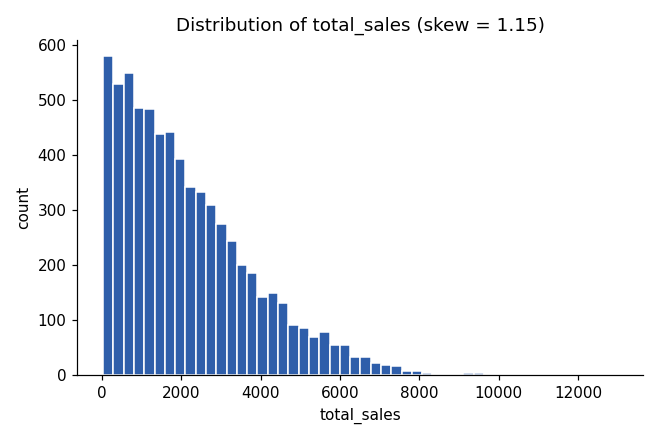

In [ ]:
# Exploratory Data Analysis
fig1 = plt.imread
# Distribution of the target
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(train.total_sales, bins=50, color='#2E5EAA', edgecolor='white')
ax.set_xlabel('total_sales'); ax.set_ylabel('count')
ax.set_title(f'Distribution of total_sales (skew = {train.total_sales.skew():.2f})')
plt.show()

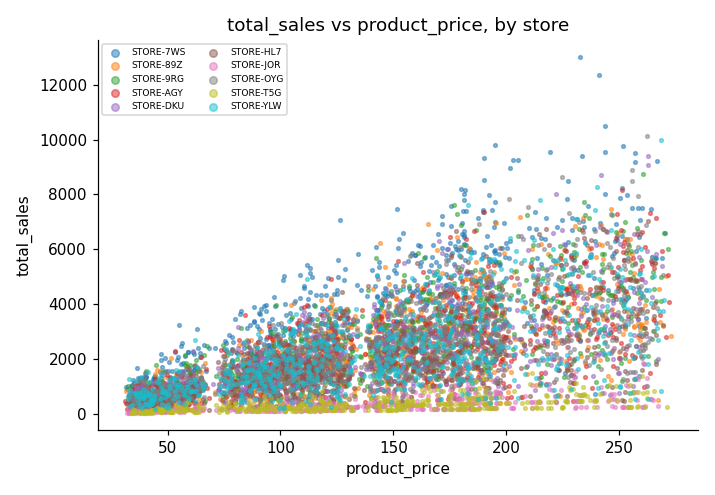

In [ ]:
# Total_sales vs product_price, by store
fig, ax = plt.subplots(figsize=(6.5,4.5))
cmap = plt.get_cmap('tab10')
for i, s in enumerate(sorted(train.store_code.unique())):
    d = train[train.store_code == s]
    ax.scatter(d.product_price, d.total_sales, s=6, alpha=0.5, color=cmap(i % 10), label=s)
ax.set_xlabel('product_price'); ax.set_ylabel('total_sales')
ax.set_title('total_sales vs product_price, by store')
ax.legend(fontsize=6, ncol=2, markerscale=2, loc='upper left')
plt.show()

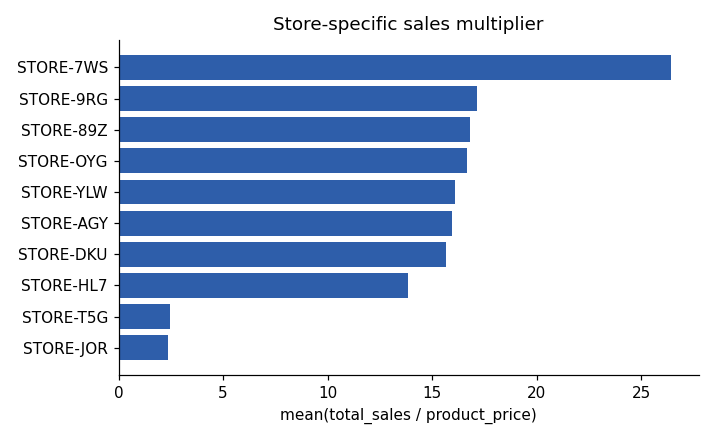

In [ ]:
train['ratio'] = train.total_sales / train.product_price
store_mult = train.groupby('store_code').ratio.mean().sort_values()

fig, ax = plt.subplots(figsize=(6.5,4))
ax.barh(store_mult.index, store_mult.values, color='#2E5EAA')
ax.set_xlabel('mean(total_sales / product_price)')
ax.set_title('Store-specific sales multiplier')
plt.show()

store_mult

In [ ]:
# Cross Validation
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def cv_score(predict_fn, df, n_splits=5, n_repeats=5, seed=7):
    """predict_fn(train_fold, val_fold) -> predictions for val_fold rows."""
    y = df['total_sales'].values
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    scores = []
    for tr_idx, val_idx in rkf.split(df):
        preds = predict_fn(df.iloc[tr_idx], df.iloc[val_idx])
        scores.append(rmse(y[val_idx], preds))
    return np.array(scores)

In [ ]:
# Modelling
def predict_A(train_fold, val_fold):
    ratio = train_fold['total_sales'] / train_fold['product_price']
    store_mult = ratio.groupby(train_fold['store_code']).mean()
    return val_fold['product_price'].values * val_fold['store_code'].map(store_mult).values

scores_A = cv_score(predict_A, train)
print(f'Model A: {scores_A.mean():.2f} ± {scores_A.std()/np.sqrt(len(scores_A)):.2f}')

Model A: 1071.17 ± 6.32


In [ ]:
# Model C — Model A refined with a shrunk product-level effect
def predict_C(train_fold, val_fold, k=50):
    ratio = train_fold['total_sales'] / train_fold['product_price']
    store_mult = ratio.groupby(train_fold['store_code']).mean()
    norm_ratio = ratio / train_fold['store_code'].map(store_mult).values

    prod_stats = norm_ratio.groupby(train_fold['product_code']).agg(['sum', 'count'])
    s = val_fold['product_code'].map(prod_stats['sum']).fillna(0).values
    n = val_fold['product_code'].map(prod_stats['count']).fillna(0).values
    prod_mult = (s + k) / (n + k)

    return (val_fold['product_price'].values
            * val_fold['store_code'].map(store_mult).values
            * prod_mult)

scores_C = cv_score(predict_C, train)
print(f'Model C (k=50): {scores_C.mean():.2f} ± {scores_C.std()/np.sqrt(len(scores_C)):.2f}')

Model C (k=50): 1070.35 ± 6.40


In [ ]:
# Generate Prediction
train['ratio'] = train['total_sales'] / train['product_price']
store_mult = train.groupby('store_code')['ratio'].mean()
pred_A = test['product_price'] * test['store_code'].map(store_mult)

train['nr'] = train['ratio'] / train['store_code'].map(store_mult)
prod_stats = train.groupby('product_code')['nr'].agg(['sum', 'count'])
k = 50
test_sum = test['product_code'].map(prod_stats['sum']).fillna(0)
test_cnt = test['product_code'].map(prod_stats['count']).fillna(0)
prod_mult = (test_sum + k) / (test_cnt + k)
pred_C = test['product_price'] * test['store_code'].map(store_mult) * prod_mult

test['total_sales'] = 0.5 * pred_A + 0.5 * pred_C

submission = sample[['id']].merge(test[['id', 'total_sales']], on='id', how='left')
submission.to_csv('submission.csv', index=False)
submission.describe()

        total_sales
count   1705.000000
mean    2191.967950
std     1328.732860
min       79.115395
25%     1187.604798
50%     2072.129967
75%     3044.972748
max     6905.097298
